# Dyadic Head-Motion Analysis: Temporal Synchrony, Social Synchrony, Proxemics

Two-person VR session (`8-1_position_rotation.csv`, `8-2_position_rotation.csv`).
Each file is one person's head + hand position (m) and rotation (deg, Euler)
tracked at ~29 Hz for the whole session.

This notebook:
1. Loads both CSVs and shows the raw dataframe shape.
2. Resamples each person onto a common uniform time grid at **1 Hz** and **30 Hz**
   (this also solves cross-person time alignment — both people land on the same
   clock, so no separate nearest-timestamp matching step is needed downstream).
3. Runs three analyses, each producing one plot:
   - **Temporal synchrony** — direct port of `SessionSynchrony.cs` / `session_synchrony.py`:
     frame-to-frame 3D head-position distance per person, windowed (1s) Pearson
     correlation between the two people's distance series, normalized to [0, 1].
   - **Social synchrony** — windowed Pearson r of *horizontal-plane* (x, z) movement
     amplitude between the pair, following the `pair_sync_scores` pattern.
   - **Proxemics** — pairwise 3D Euclidean distance between the two people over
     time, with Hall's proxemic zone breakdown (intimate / personal / social / public).

Note: the social-synchrony boxplot code this was modeled on (ConfLab) compared
within-group vs cross-group pairs across many episodes/conditions. We only have
one dyad and one continuous session here, so per your steer, the social-synchrony
plot below is a **single distribution** for this pair (no cross-group baseline).

## 1. Imports & configuration

In [1]:
import numpy as np
import pandas as pd
import scipy.stats
import scipy.spatial.distance
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

DATA_DIR = Path('.')
CSV_A = DATA_DIR / '8-1_position_rotation.csv'
CSV_B = DATA_DIR / '8-2_position_rotation.csv'

SYNC_WINDOW_S = 1.0      # window length for both synchrony analyses
PURPLE = '#7b6bd6'
ORANGE = '#e08a3c'
BLUE   = '#3b6fb6'

## 2. Load the raw CSVs

Semicolon-delimited, one row per tracked frame per person. `position_*` is head
position (m); `rotation_*` is head rotation (deg, Euler xyz); `left_hand_*` /
`right_hand_*` are hand position + rotation (not used in the analyses below —
we're focused on head motion — but loaded so they're available if you want to
extend this).

In [2]:
raw_a = pd.read_csv(CSV_A, sep=';')
raw_b = pd.read_csv(CSV_B, sep=';')

print('Person A (8-1):', raw_a.shape)
print('Person B (8-2):', raw_b.shape)
raw_a.head()

Person A (8-1): (28675, 20)
Person B (8-2): (28632, 20)


,utc_timestamp_ms,participant_id,position_x,position_y,position_z,rotation_x,rotation_y,rotation_z,left_hand_position_x,left_hand_position_y,left_hand_position_z,right_hand_position_x,right_hand_position_y,right_hand_position_z,left_hand_rotation_x,left_hand_rotation_y,left_hand_rotation_z,right_hand_rotation_x,right_hand_rotation_y,right_hand_rotation_z
0,1.782307e+12,1,-5.360913,-2.414660,0.988270,358.5654,84.09101,215.6122,-5.222950,-2.193258,0.330182,0.000000,0.000000,0.000000,357.2315,265.3522,149.1852,0.0000,0.00000,0.0000
1,1.782307e+12,1,-5.360918,-2.414667,0.988270,358.5660,84.09113,215.6089,-5.222950,-2.193258,0.330182,-5.521457,-2.602808,0.337104,357.2315,265.3522,149.1852,359.4841,76.37319,284.4571
2,1.782307e+12,1,-5.360923,-2.414672,0.988271,358.5677,84.09110,215.6115,-5.222958,-2.193269,0.330193,-5.521466,-2.602815,0.337092,357.2316,265.3522,149.1819,359.4841,76.37308,284.4536
3,1.782307e+12,1,-5.360923,-2.414673,0.988270,358.5679,84.09112,215.6119,-5.222944,-2.193279,0.330198,-5.521479,-2.602810,0.337089,357.2316,265.3522,149.1850,359.4841,76.37312,284.4568
4,1.782307e+12,1,-5.360909,-2.414673,0.988267,358.5640,84.09491,215.6145,-5.222931,-2.193292,0.330195,-5.521479,-2.602810,0.337089,357.2316,265.3523,149.1878,359.4841,76.37312,284.4568


In [3]:
raw_a.dtypes

utc_timestamp_ms         float64
participant_id             int64
position_x               float64
position_y               float64
position_z               float64
rotation_x               float64
rotation_y               float64
rotation_z               float64
left_hand_position_x     float64
left_hand_position_y     float64
left_hand_position_z     float64
right_hand_position_x    float64
right_hand_position_y    float64
right_hand_position_z    float64
left_hand_rotation_x     float64
left_hand_rotation_y     float64
left_hand_rotation_z     float64
right_hand_rotation_x    float64
right_hand_rotation_y    float64
right_hand_rotation_z    float64
dtype: object

In [4]:
# Native sampling interval (ms) -- irregular VR tracking rate, ~29 Hz nominal
for name, df in [('A', raw_a), ('B', raw_b)]:
    dt = df['utc_timestamp_ms'].diff().dropna()
    print(f"Person {name}: median dt={dt.median():.2f} ms  (~{1000/dt.median():.1f} Hz), "
          f"n={len(df)}, duration={(df['utc_timestamp_ms'].max()-df['utc_timestamp_ms'].min())/1000:.1f} s")

Person A: median dt=34.44 ms  (~29.0 Hz), n=28675, duration=1003.8 s
Person B: median dt=34.48 ms  (~29.0 Hz), n=28632, duration=1003.7 s


In [5]:
# Combine into one long-format dataframe with a participant_id column,
# analogous to the uuid-indexed dataframes in the pasted reference code.
raw_a2 = raw_a.copy(); raw_a2['participant_id'] = 'A'
raw_b2 = raw_b.copy(); raw_b2['participant_id'] = 'B'
combined = pd.concat([raw_a2, raw_b2], ignore_index=True)
combined['t_s'] = combined['utc_timestamp_ms'] / 1000.0
combined = combined.sort_values(['participant_id', 't_s']).reset_index(drop=True)
combined[['participant_id', 't_s', 'position_x', 'position_y', 'position_z',
          'rotation_x', 'rotation_y', 'rotation_z']].head()

,participant_id,t_s,position_x,position_y,position_z,rotation_x,rotation_y,rotation_z
0,A,1.782307e+09,-5.360913,-2.414660,0.988270,358.5654,84.09101,215.6122
1,A,1.782307e+09,-5.360918,-2.414667,0.988270,358.5660,84.09113,215.6089
2,A,1.782307e+09,-5.360923,-2.414672,0.988271,358.5677,84.09110,215.6115
3,A,1.782307e+09,-5.360923,-2.414673,0.988270,358.5679,84.09112,215.6119
4,A,1.782307e+09,-5.360909,-2.414673,0.988267,358.5640,84.09491,215.6145


## 3. Resample to 1 Hz and 30 Hz

Each person's position/rotation streams are linearly interpolated onto a
shared uniform time grid (session-start to session-end) at the target rate.
Because both people are interpolated onto the *same* grid, this simultaneously
solves cross-person synchronization -- every downstream analysis can just index
by time and the two people's rows already line up.

In [6]:
def resample_person(df, rate_hz, t0, t1):
    """Interpolate one person's position+rotation columns onto a uniform grid
    at `rate_hz`, spanning [t0, t1]."""
    cols = ['position_x', 'position_y', 'position_z',
            'rotation_x', 'rotation_y', 'rotation_z']
    d = df.sort_values('t_s').drop_duplicates('t_s').set_index('t_s')[cols]
    grid = np.arange(t0, t1, 1.0 / rate_hz)
    out = pd.DataFrame(index=grid)
    out.index.name = 't_s'
    for c in cols:
        out[c] = np.interp(grid, d.index.to_numpy(), d[c].to_numpy())
    return out.reset_index()


def resample_session(raw_a, raw_b, rate_hz):
    a = raw_a.copy(); a['t_s'] = a['utc_timestamp_ms'] / 1000.0
    b = raw_b.copy(); b['t_s'] = b['utc_timestamp_ms'] / 1000.0
    t0 = max(a['t_s'].min(), b['t_s'].min())
    t1 = min(a['t_s'].max(), b['t_s'].max())
    res_a = resample_person(a, rate_hz, t0, t1)
    res_b = resample_person(b, rate_hz, t0, t1)
    res_a['session_time_s'] = res_a['t_s'] - t0
    res_b['session_time_s'] = res_b['t_s'] - t0
    return res_a, res_b


session_a_1hz, session_b_1hz = resample_session(raw_a, raw_b, rate_hz=1.0)
session_a_30hz, session_b_30hz = resample_session(raw_a, raw_b, rate_hz=30.0)

print('1 Hz  grid:', session_a_1hz.shape, ' -- one row per second, whole session')
print('30 Hz grid:', session_a_30hz.shape)
session_a_30hz.head()

1 Hz  grid: (1004, 8)  -- one row per second, whole session
30 Hz grid: (30112, 8)


,t_s,position_x,position_y,position_z,rotation_x,rotation_y,rotation_z,session_time_s
0,1.782307e+09,-5.360914,-2.414662,0.988270,358.565542,84.091038,215.611417,0.000000
1,1.782307e+09,-5.360919,-2.414668,0.988270,358.566347,84.091124,215.609431,0.033333
2,1.782307e+09,-5.360923,-2.414672,0.988270,358.567740,84.091104,215.611579,0.066667
3,1.782307e+09,-5.360921,-2.414673,0.988270,358.567357,84.091648,215.612262,0.100000
4,1.782307e+09,-5.360910,-2.414674,0.988267,358.564846,84.094953,215.614121,0.133333


In [7]:
session_a_1hz.head()

,t_s,position_x,position_y,position_z,rotation_x,rotation_y,rotation_z,session_time_s
0,1.782307e+09,-5.360914,-2.414662,0.988270,358.565542,84.091038,215.611417,0.0
1,1.782307e+09,-5.360916,-2.414663,0.988270,358.564623,84.091297,215.613153,1.0
2,1.782307e+09,-5.360925,-2.414675,0.988270,358.570145,84.091272,215.612574,2.0
3,1.782307e+09,-5.360930,-2.414676,0.988514,358.572506,84.089881,215.610197,3.0
4,1.782307e+09,-5.360919,-2.414674,0.988514,358.569700,84.092000,215.611300,4.0


## 4. Temporal synchrony

Direct port of `SessionSynchrony.cs` / `session_synchrony.py`: frame-to-frame
3D head-position distance per person, computed on the 30 Hz grid (so each 1s
window carries exactly 30 samples), windowed Pearson correlation between the
two distance series in each non-overlapping 1s window, normalized `(r+1)/2`
onto [0, 1].

In [8]:
def head_distance_series(df):
    pos = df[['position_x', 'position_y', 'position_z']].to_numpy()
    d = np.zeros(len(pos))
    d[1:] = np.linalg.norm(np.diff(pos, axis=0), axis=1)
    return d


def normalize_sync_score(r):
    return (r + 1.0) / 2.0


def pearson_safe(a, b):
    if len(a) == 0 or len(a) != len(b):
        return 0.0
    da, db = a - a.mean(), b - b.mean()
    den_a, den_b = np.sum(da * da), np.sum(db * db)
    if den_a == 0 or den_b == 0:
        return 0.0
    return float(np.sum(da * db) / np.sqrt(den_a * den_b))


def temporal_synchrony(df_a_30hz, df_b_30hz, fs=30.0, window_s=SYNC_WINDOW_S):
    dist_a = head_distance_series(df_a_30hz)
    dist_b = head_distance_series(df_b_30hz)
    t = df_a_30hz['session_time_s'].to_numpy()

    win = int(window_s * fs)
    n_windows = len(t) // win
    rows = []
    for i in range(n_windows):
        sl = slice(i * win, (i + 1) * win)
        r = pearson_safe(dist_a[sl], dist_b[sl])
        rows.append({'session_time_s': t[sl][0], 'pearson_r': r,
                     'synchrony': normalize_sync_score(r)})
    return pd.DataFrame(rows)


temporal_sync = temporal_synchrony(session_a_30hz, session_b_30hz)
print(f"windows: {len(temporal_sync)}  mean synchrony: {temporal_sync['synchrony'].mean():.4f}"
      f"  mean pearson r: {temporal_sync['pearson_r'].mean():.4f}")
temporal_sync.head()

windows: 1003  mean synchrony: 0.5218  mean pearson r: 0.0437


,session_time_s,pearson_r,synchrony
0,0.000000,-0.202268,0.398866
1,0.999999,0.395754,0.697877
2,1.999998,0.337133,0.668567
3,2.999997,0.413524,0.706762
4,3.999996,-0.105652,0.447174


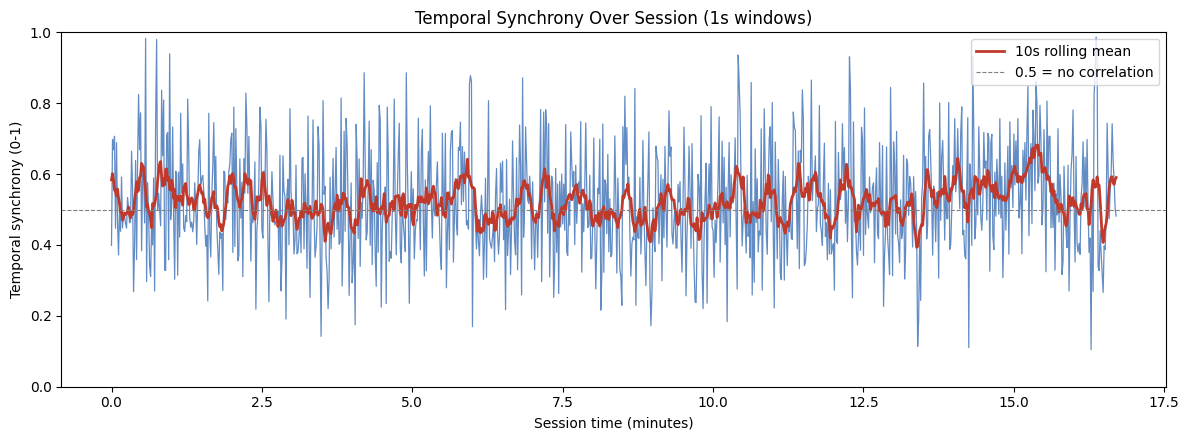

Saved temporal_synchrony.png


In [9]:
# --- Plot 1: Temporal synchrony over the whole session ---
fig, ax = plt.subplots(figsize=(12, 4.5))
minutes = temporal_sync['session_time_s'] / 60.0
ax.plot(minutes, temporal_sync['synchrony'], linewidth=0.9, color=BLUE, alpha=0.8)
roll = temporal_sync['synchrony'].rolling(10, center=True, min_periods=1).mean()
ax.plot(minutes, roll, linewidth=2.0, color='#c0392b', label='10s rolling mean')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='0.5 = no correlation')
ax.set_xlabel('Session time (minutes)')
ax.set_ylabel('Temporal synchrony (0-1)')
ax.set_title('Temporal Synchrony Over Session (1s windows)')
ax.set_ylim(0, 1)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('temporal_synchrony.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved temporal_synchrony.png')

## 5. Social synchrony

Windowed Pearson r of **horizontal-plane** (x, z) movement amplitude between
the pair — the `pair_sync_scores` pattern. Differs from temporal synchrony
above in two ways: it uses only the x/z (floor-plane) movement rather than
full 3D distance, and it returns a *distribution* of per-window scores for
the pair rather than a continuous time-indexed series.

Per your steer, since we only have this one dyad/session (no other
groups or conditions to serve as a cross-group baseline), this is plotted as
a single distribution for the pair rather than a within- vs cross-group
comparison.

In [10]:
def pair_sync_scores(df_a, df_b, fps=30.0, window_s=SYNC_WINDOW_S):
    """Windowed Pearson r of horizontal-plane (x, z) movement amplitude
    between two people, on a shared time grid (already-resampled/aligned
    dataframes with position_x / position_z columns)."""
    ab = df_a[['session_time_s', 'position_x', 'position_z']].merge(
        df_b[['session_time_s', 'position_x', 'position_z']],
        on='session_time_s', suffixes=('_a', '_b'))
    if len(ab) < fps * window_s * 2:
        return []

    amp_a = np.sqrt(ab['position_x_a'].diff()**2 + ab['position_z_a'].diff()**2).dropna().to_numpy()
    amp_b = np.sqrt(ab['position_x_b'].diff()**2 + ab['position_z_b'].diff()**2).dropna().to_numpy()
    n = min(len(amp_a), len(amp_b))
    amp_a, amp_b = amp_a[:n], amp_b[:n]

    W = int(fps * window_s)
    scores = []
    for start in range(0, n - W, W):
        sa, sb = amp_a[start:start + W], amp_b[start:start + W]
        if np.std(sa) < 1e-6 or np.std(sb) < 1e-6:
            continue
        r, _ = scipy.stats.pearsonr(sa, sb)
        if not np.isnan(r):
            scores.append(r)
    return scores


social_sync_scores = pair_sync_scores(session_a_30hz, session_b_30hz)
print(f'Social-synchrony windows: {len(social_sync_scores)}')
print(f'Mean r = {np.mean(social_sync_scores):.3f}   '
      f'median r = {np.median(social_sync_scores):.3f}   '
      f'SD = {np.std(social_sync_scores):.3f}')

Social-synchrony windows: 1001
Mean r = 0.044   median r = 0.015   SD = 0.312


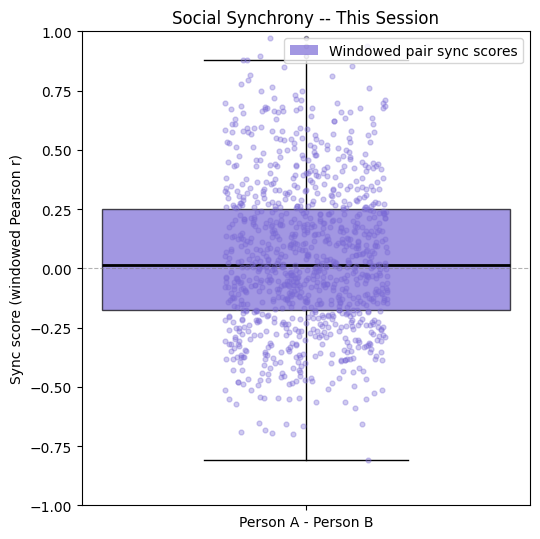

Saved social_synchrony_boxplot.png


In [11]:
# --- Plot 2: Social synchrony distribution for this pair ---
fig, ax = plt.subplots(figsize=(5.5, 5.5))

bp = ax.boxplot([social_sync_scores], positions=[0], widths=0.4,
                 patch_artist=True, manage_ticks=False,
                 boxprops=dict(facecolor=PURPLE, alpha=0.7),
                 medianprops=dict(color='black', lw=2),
                 flierprops=dict(marker='o', markersize=3, alpha=0.4, markerfacecolor=PURPLE))

# jittered scatter of the underlying window scores
jitter = np.random.uniform(-0.08, 0.08, size=len(social_sync_scores))
ax.scatter(jitter, social_sync_scores, color=PURPLE, alpha=0.35, s=12, zorder=3)

ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.set_xticks([0])
ax.set_xticklabels(['Person A - Person B'])
ax.set_ylabel('Sync score (windowed Pearson r)')
ax.set_ylim(-1, 1)
ax.set_title('Social Synchrony -- This Session')

legend_patches = [mpatches.Patch(facecolor=PURPLE, alpha=0.7, label='Windowed pair sync scores')]
ax.legend(handles=legend_patches, loc='upper right')
plt.tight_layout()
plt.savefig('social_synchrony_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved social_synchrony_boxplot.png')

## 6. Proxemic analysis

Pairwise 3D Euclidean distance between the two people's heads at each
timestamp (`scipy.spatial.distance.pdist`, generalizes to >2 people if this
is ever extended beyond a dyad), computed on the **1 Hz** grid — proxemic
distance doesn't need 30 Hz precision, and 1 Hz keeps the zone-percentage
counting simple. Zone boundaries follow Hall's proxemic distances: intimate
< 0.46 m, personal 0.46-1.2 m, social 1.2-3.6 m, public >= 3.6 m.

In [12]:
def compute_proxemics(df_a, df_b):
    """All pairwise 3D distances at each shared timestamp. Written to
    generalize past a dyad (pdist over however many people are present at
    each timestamp), even though we only have two people here."""
    merged = df_a[['session_time_s', 'position_x', 'position_y', 'position_z']].merge(
        df_b[['session_time_s', 'position_x', 'position_y', 'position_z']],
        on='session_time_s', suffixes=('_a', '_b'))

    dists = []
    for _, row in merged.iterrows():
        xyz = np.array([
            [row['position_x_a'], row['position_y_a'], row['position_z_a']],
            [row['position_x_b'], row['position_y_b'], row['position_z_b']],
        ])
        dists.extend(scipy.spatial.distance.pdist(xyz, 'euclidean').tolist())

    return merged['session_time_s'].to_numpy(), np.array(dists)


prox_time_s, prox_dists = compute_proxemics(session_a_1hz, session_b_1hz)
print(f'Proxemic samples: {len(prox_dists)}')
print(f'Mean distance: {prox_dists.mean():.3f} m   SD: {prox_dists.std():.3f} m   '
      f'min: {prox_dists.min():.3f} m   max: {prox_dists.max():.3f} m')

Proxemic samples: 1004
Mean distance: 1.137 m   SD: 0.276 m   min: 0.153 m   max: 4.761 m


In [13]:
print('=== Hall proxemic zone breakdown ===')
n = len(prox_dists)
intimate = 100 * (prox_dists < 0.46).sum() / n
personal = 100 * ((prox_dists >= 0.46) & (prox_dists < 1.2)).sum() / n
social   = 100 * ((prox_dists >= 1.2) & (prox_dists < 3.6)).sum() / n
public   = 100 * (prox_dists >= 3.6).sum() / n
print(f'intimate={intimate:.1f}%  personal={personal:.1f}%  social={social:.1f}%  public={public:.1f}%')

=== Hall proxemic zone breakdown ===
intimate=3.1%  personal=66.6%  social=30.2%  public=0.1%


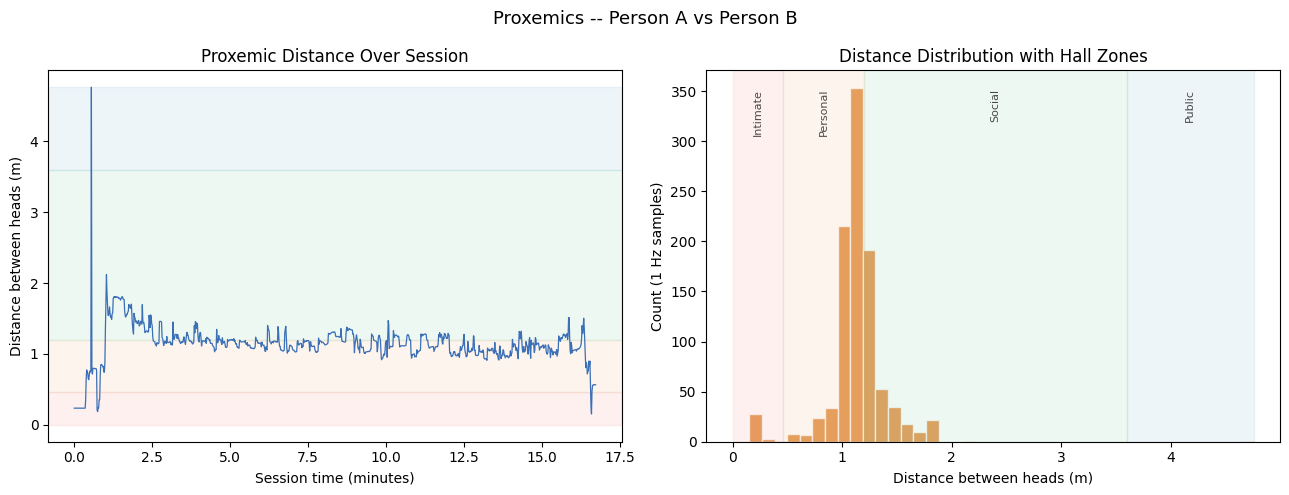

Saved proxemics.png


In [14]:
# --- Plot 3: Proxemics over time + distribution with Hall zones ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
zone_bands = [(0, 0.46, '#e74c3c', 'Intimate'), (0.46, 1.2, '#e67e22', 'Personal'),
              (1.2, 3.6, '#27ae60', 'Social'), (3.6, max(prox_dists.max(), 4.0), '#2980b9', 'Public')]
for lo, hi, color, label in zone_bands:
    ax.axhspan(lo, hi, color=color, alpha=0.08)
ax.plot(prox_time_s / 60.0, prox_dists, color=BLUE, linewidth=0.9)
ax.set_xlabel('Session time (minutes)')
ax.set_ylabel('Distance between heads (m)')
ax.set_title('Proxemic Distance Over Session')

ax2 = axes[1]
ax2.hist(prox_dists, bins=40, color=ORANGE, alpha=0.8, edgecolor='white')
for lo, hi, color, label in zone_bands:
    ax2.axvspan(lo, hi, color=color, alpha=0.08)
    ax2.text((lo + min(hi, prox_dists.max())) / 2, ax2.get_ylim()[1] * 0.95, label,
              ha='center', va='top', fontsize=8, rotation=90, alpha=0.7)
ax2.set_xlabel('Distance between heads (m)')
ax2.set_ylabel('Count (1 Hz samples)')
ax2.set_title('Distance Distribution with Hall Zones')

plt.suptitle('Proxemics -- Person A vs Person B', fontsize=13)
plt.tight_layout()
plt.savefig('proxemics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved proxemics.png')

## 7. Summary

In [15]:
print('=== Summary ===')
print(f"Temporal synchrony:  mean={temporal_sync['synchrony'].mean():.3f}  "
      f"(0.5 = chance; {len(temporal_sync)} one-second windows)")
print(f"Social synchrony:    mean r={np.mean(social_sync_scores):.3f}  "
      f"({len(social_sync_scores)} windows)")
print(f"Proxemics:           mean distance={prox_dists.mean():.3f} m  "
      f"(intimate={intimate:.1f}%, personal={personal:.1f}%, social={social:.1f}%, public={public:.1f}%)")

=== Summary ===
Temporal synchrony:  mean=0.522  (0.5 = chance; 1003 one-second windows)
Social synchrony:    mean r=0.044  (1001 windows)
Proxemics:           mean distance=1.137 m  (intimate=3.1%, personal=66.6%, social=30.2%, public=0.1%)
